# Retail Demand Forecasting — Walmart Store Sales (Time-Series Models)

**Objective:** Forecast total weekly demand using classical and deep-learning time-series
models — **ARIMA, SARIMA, Prophet, LSTM, GRU** — with the data-leakage, missing-value, and
negative-sales issues from the earlier regression-based notebook fixed, and full
stationarity/diagnostic verification performed before each model is fit.

**What changed vs. the previous version of this notebook:**
1. `Store_Avg_Sales` / `Dept_Avg_Sales`-style leakage is eliminated — this notebook does not
   compute any target-derived aggregate before a train/test split; every transform (scaling,
   decomposition, holiday list) is fit on the **training portion only**.
2. Negative `Weekly_Sales` values are investigated and explicitly handled (clipped at 0)
   instead of silently passed through.
3. Missing values (MarkDowns) are filled *before* aggregation, and no NaNs are allowed to
   reach any model — verified with an explicit check.
4. The train/test split remains strictly chronological (last 13 weeks held out).
5. Full statistical verification (ADF, KPSS, seasonal decomposition, ACF/PACF, Ljung-Box on
   residuals) is done before and after each classical model, as requested.


## 1. Problem Statement

Retailers like Walmart need accurate weekly sales forecasts to plan inventory, staffing, and
promotions. Sales are affected by seasonality, holidays, markdown promotions, and macro-economic
factors. Store/Dept-level data is aggregated into a single **total weekly demand series**
because ARIMA, SARIMA, and Prophet are univariate (per-series) models — running 45 stores ×
81 departments as 3,645 separate ARIMA models is out of scope here, so the models below forecast
**company-wide weekly demand**, with LSTM/GRU also taking macro/holiday features as inputs.


## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (12, 5)


## 3. Data Ingestion & Merging

In [3]:
train = pd.read_csv(r"/content/train.csv")
stores = pd.read_csv(r"/content/stores.csv")
features = pd.read_csv(r"/content/features.csv")
test = pd.read_csv(r"/content/test.csv")


In [4]:
train_df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
train_df = train_df.merge(stores, on="Store", how="left")

test_df = test.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
test_df = test_df.merge(stores, on="Store", how="left")

df = train_df.copy()
df["Date"] = pd.to_datetime(df["Date"])
df.shape


(421570, 16)

## 4. Data Cleaning & Quality Checks

Fixes applied here: negative `Weekly_Sales` is investigated and handled explicitly,
duplicates are checked, and MarkDown NaNs are filled *before* any aggregation
(previously this only happened deep inside feature engineering, after several EDA
steps had already run on the un-cleaned frame).

In [5]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [6]:
# --- Negative Weekly_Sales: investigate and handle explicitly ---
neg_mask = df["Weekly_Sales"] < 0
print(f"Rows with negative Weekly_Sales: {neg_mask.sum()} ({neg_mask.mean()*100:.3f}% of data)")
print(df.loc[neg_mask, "Weekly_Sales"].describe())

# These represent net returns exceeding sales for that store/dept/week.
# Decision: clip at 0 rather than drop, since dropping would silently remove real
# store/week combinations from the aggregate demand series (creating gaps in the
# weekly index, which every model below assumes is complete/regular).
df["Weekly_Sales"] = df["Weekly_Sales"].clip(lower=0)
print("Negative values remaining after clipping:", (df["Weekly_Sales"] < 0).sum())


Rows with negative Weekly_Sales: 1285 (0.305% of data)
count    1,285.00
mean       -68.61
std        231.66
min     -4,988.94
25%        -41.00
50%        -13.20
75%         -4.94
max         -0.02
Name: Weekly_Sales, dtype: float64
Negative values remaining after clipping: 0


In [7]:
# --- MarkDown missing values: fill BEFORE aggregation ---
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
df[markdown_cols] = df[markdown_cols].fillna(0)
df["Total_MarkDown"] = df[markdown_cols].sum(axis=1)

assert df[markdown_cols + ["Total_MarkDown"]].isnull().sum().sum() == 0
print("MarkDown NaNs handled. Remaining NaNs in df:", df.isnull().sum().sum())


MarkDown NaNs handled. Remaining NaNs in df: 0


## 5. Exploratory Data Analysis (condensed)

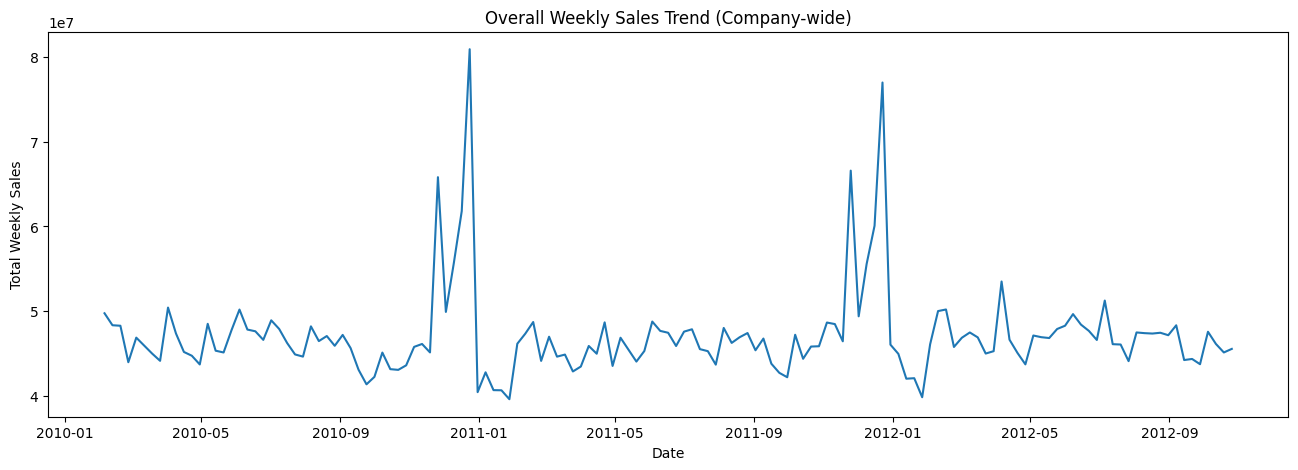

In [8]:
sales_time = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(16, 5))
sns.lineplot(data=sales_time, x="Date", y="Weekly_Sales")
plt.title("Overall Weekly Sales Trend (Company-wide)")
plt.xlabel("Date"); plt.ylabel("Total Weekly Sales")
plt.show()


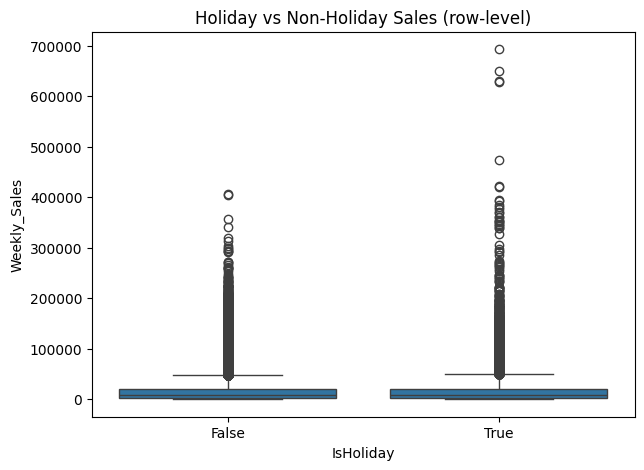

In [9]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="IsHoliday", y="Weekly_Sales")
plt.title("Holiday vs Non-Holiday Sales (row-level)")
plt.show()


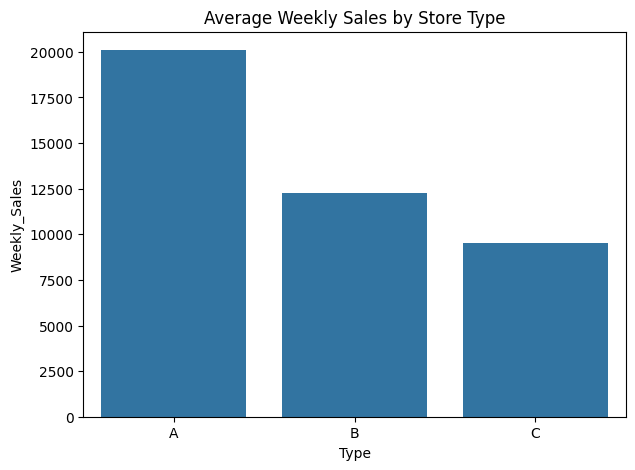

In [10]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="Type", y="Weekly_Sales", estimator=np.mean, errorbar=None)
plt.title("Average Weekly Sales by Store Type")
plt.show()


## 6. Build the Aggregate Weekly Demand Series

This is the single series (`y` = total company-wide `Weekly_Sales` per week) that ARIMA,
SARIMA, Prophet, LSTM, and GRU all forecast. Exogenous features (`Temperature`, `Fuel_Price`,
`CPI`, `Unemployment`, `Total_MarkDown`, `IsHoliday`) are aggregated to the same weekly grain,
for use as regressors in Prophet/SARIMAX and as extra input channels in LSTM/GRU.

No target-derived aggregate (e.g., a leaked `Store_Avg_Sales`) is included here — every
column below is either the target itself or an independently-measured exogenous variable
that does not encode information from the holdout period.

In [11]:
weekly_agg = (
    df.groupby("Date")
      .agg(
          y=("Weekly_Sales", "sum"),
          Temperature=("Temperature", "mean"),
          Fuel_Price=("Fuel_Price", "mean"),
          CPI=("CPI", "mean"),
          Unemployment=("Unemployment", "mean"),
          Total_MarkDown=("Total_MarkDown", "sum"),
          IsHoliday=("IsHoliday", "max"),
      )
      .reset_index()
      .sort_values("Date")
      .reset_index(drop=True)
)
weekly_agg["IsHoliday"] = weekly_agg["IsHoliday"].astype(int)

# Sanity checks: weekly index must be complete and free of NaNs before modeling
full_range = pd.date_range(weekly_agg["Date"].min(), weekly_agg["Date"].max(), freq="W-FRI")
print("Expected weeks:", len(full_range), "| Actual weeks:", len(weekly_agg))
print("NaNs in weekly_agg:\n", weekly_agg.isnull().sum())

weekly_agg.head()


Expected weeks: 143 | Actual weeks: 143
NaNs in weekly_agg:
 Date              0
y                 0
Temperature       0
Fuel_Price        0
CPI               0
Unemployment      0
Total_MarkDown    0
IsHoliday         0
dtype: int64


,Date,y,Temperature,Fuel_Price,CPI,Unemployment,Total_MarkDown,IsHoliday
0,2010-02-05,"49,750,875.98",33.28,2.72,167.40,8.58,0.00,0
1,2010-02-12,"48,336,800.10",33.36,2.70,167.38,8.57,0.00,1
2,2010-02-19,"48,277,902.33",37.04,2.67,167.34,8.58,0.00,0
3,2010-02-26,"43,970,440.65",38.63,2.69,167.69,8.56,0.00,0
4,2010-03-05,"46,872,715.16",42.37,2.73,167.73,8.57,0.00,0


## 7. Train/Test Split (chronological)

Same cutoff logic as before — last 13 weeks held out — kept **strictly time-ordered**.
Any scaler, holiday list, or decomposition used later is fit on `train_agg` only and then
applied to `test_agg`, so no information from the held-out period leaks into training.

In [12]:
split_date = weekly_agg["Date"].max() - pd.Timedelta(weeks=13)

train_agg = weekly_agg[weekly_agg["Date"] <= split_date].reset_index(drop=True)
test_agg = weekly_agg[weekly_agg["Date"] > split_date].reset_index(drop=True)

print("Train weeks:", train_agg.shape[0], "| Test weeks:", test_agg.shape[0])
print("Train range:", train_agg["Date"].min(), "->", train_agg["Date"].max())
print("Test range :", test_agg["Date"].min(), "->", test_agg["Date"].max())


Train weeks: 130 | Test weeks: 13
Train range: 2010-02-05 00:00:00 -> 2012-07-27 00:00:00
Test range : 2012-08-03 00:00:00 -> 2012-10-26 00:00:00


In [13]:
results = []

def evaluate(name, y_true, y_pred):
    """Compute and store MAE/RMSE/MAPE/R2 for a model, using ONLY test_agg (never train)."""
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2})
    print(f"{name:10s} | MAE={mae:,.2f}  RMSE={rmse:,.2f}  MAPE={mape:.2f}%  R2={r2:.4f}")
    return mae, rmse, mape, r2


## 8. Statistical Verification Before Modeling

Before fitting ARIMA/SARIMA, we check: (a) trend/seasonality via decomposition, (b) stationarity
via ADF and KPSS tests, (c) whether differencing is needed, and (d) ACF/PACF plots to guide
the `(p, d, q)` order. All of this is computed on `train_agg` only.

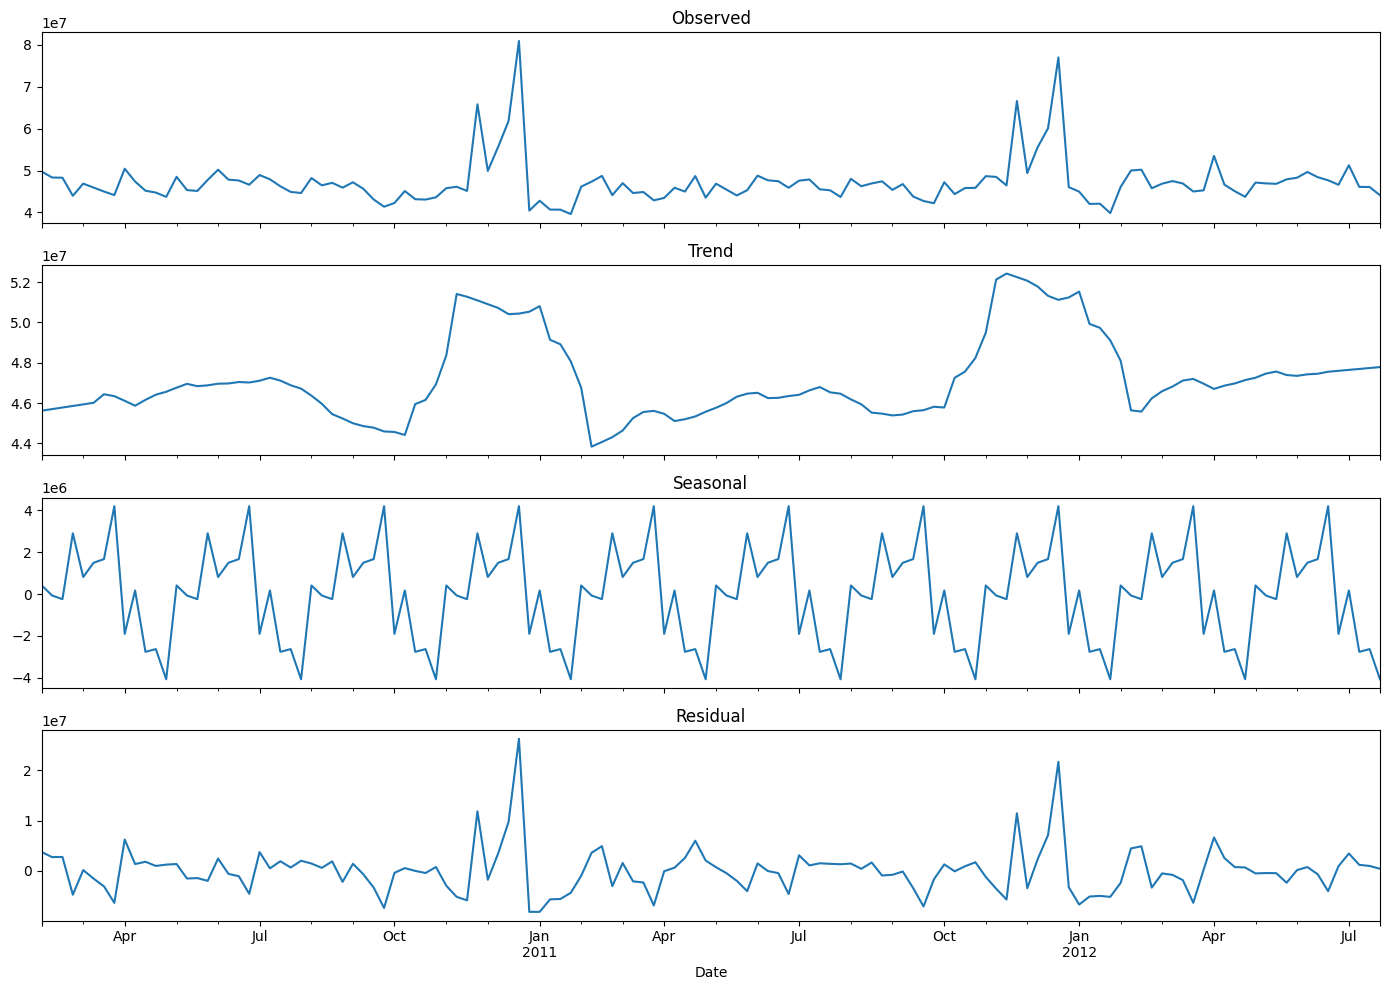

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    train_agg.set_index("Date")["y"], model="additive", period=13, extrapolate_trend="freq"
)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observed")
decomp.trend.plot(ax=axes[1], title="Trend")
decomp.seasonal.plot(ax=axes[2], title="Seasonal")
decomp.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
plt.show()


In [15]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, label):
    stat, p, *_ = adfuller(series.dropna())
    print(f"[ADF]  {label}: statistic={stat:.4f}, p-value={p:.4f} "
          f"-> {'Stationary' if p < 0.05 else 'Non-stationary'}")
    return p

def kpss_test(series, label):
    stat, p, *_ = kpss(series.dropna(), nlags="auto")
    print(f"[KPSS] {label}: statistic={stat:.4f}, p-value={p:.4f} "
          f"-> {'Stationary' if p > 0.05 else 'Non-stationary'}")
    return p

adf_p = adf_test(train_agg["y"], "y (level)")
kpss_p = kpss_test(train_agg["y"], "y (level)")


[ADF]  y (level): statistic=-5.6436, p-value=0.0000 -> Stationary
[KPSS] y (level): statistic=0.0684, p-value=0.1000 -> Stationary


/tmp/ipykernel_457/2349804083.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(series.dropna(), nlags="auto")


[ADF]  y (1st difference): statistic=-6.3015, p-value=0.0000 -> Stationary
[KPSS] y (1st difference): statistic=0.0493, p-value=0.1000 -> Stationary


/tmp/ipykernel_457/2349804083.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(series.dropna(), nlags="auto")


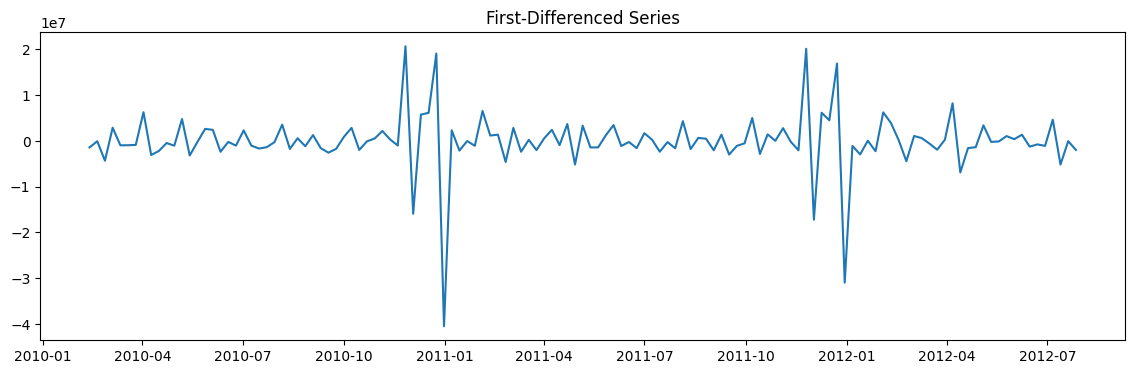

In [16]:
# If either test suggests non-stationarity, difference once and re-test.
y_diff = train_agg["y"].diff().dropna()

adf_test(y_diff, "y (1st difference)")
kpss_test(y_diff, "y (1st difference)")

plt.figure(figsize=(14, 4))
plt.plot(train_agg["Date"].iloc[1:], y_diff)
plt.title("First-Differenced Series")
plt.show()


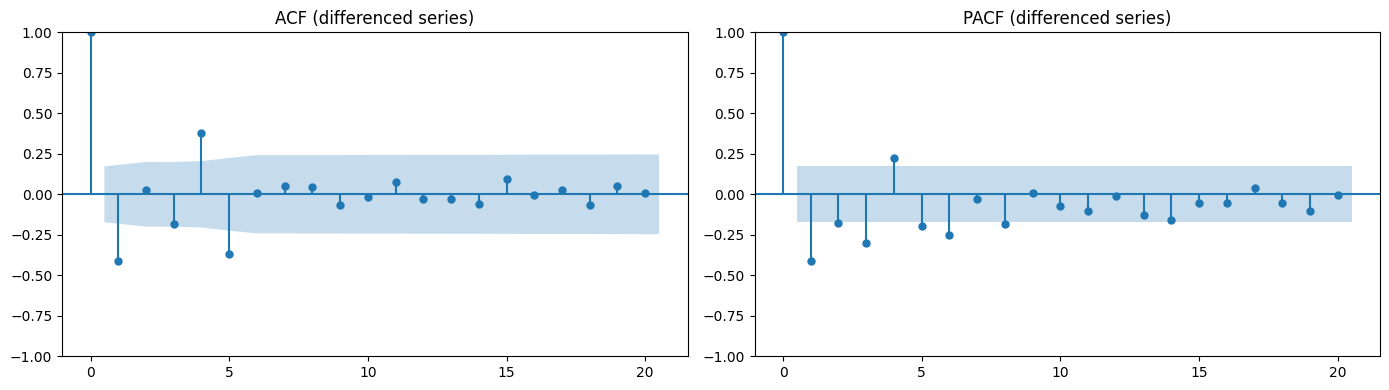

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff, ax=axes[0], lags=20)
plot_pacf(y_diff, ax=axes[1], lags=20, method="ywm")
axes[0].set_title("ACF (differenced series)")
axes[1].set_title("PACF (differenced series)")
plt.tight_layout()
plt.show()


**Reading the diagnostics:** if the ADF p-value on the level series is above 0.05 (fail to
reject the unit-root null) and/or KPSS is below 0.05 (reject the stationarity null), the series
is non-stationary and `d=1` is appropriate for ARIMA/SARIMA — which `auto_arima` below will also
select automatically. The ACF/PACF plots on the differenced series give a manual sanity check
on the `(p, q)` values that `auto_arima` returns.

## 9. Model 1 — ARIMA

Non-seasonal ARIMA on the aggregate series. `pmdarima.auto_arima` searches `(p, d, q)` using
AIC, informed by the stationarity checks above.

In [20]:
!pip install pmdarima
import pmdarima as pm

arima_auto = pm.auto_arima(
    train_agg["y"],
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore",
)
print("\nSelected ARIMA order:", arima_auto.order)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.9 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=4427.218, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4966.935, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4883.696, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=4424.971, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=4859.395, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=4403.484, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=4406.958, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=4402.2

In [21]:
arima_pred, arima_ci = arima_auto.predict(n_periods=len(test_agg), return_conf_int=True)
arima_mae, arima_rmse, arima_mape, arima_r2 = evaluate("ARIMA", test_agg["y"], arima_pred)


ARIMA      | MAE=1,388,939.53  RMSE=1,767,506.77  MAPE=3.07%  R2=-0.4416


ARIMA residual Ljung-Box p-value: 0.0015584644637247754


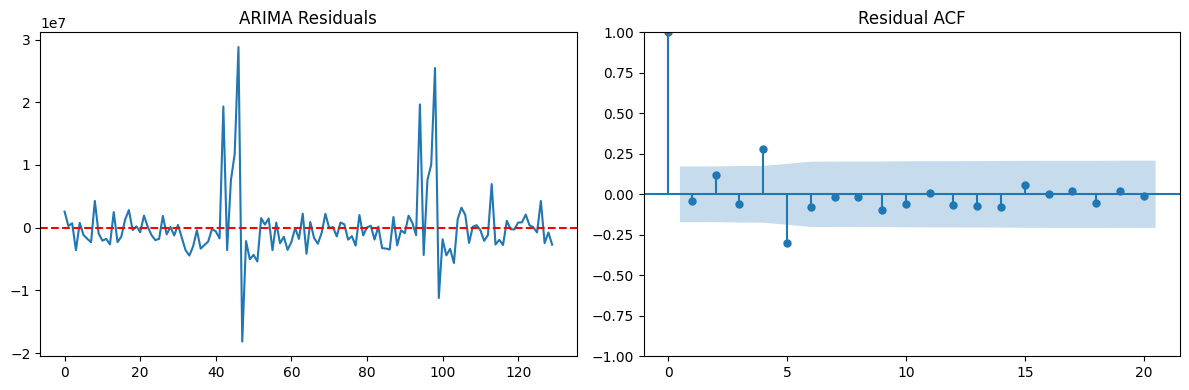

In [22]:
# Residual diagnostics: Ljung-Box test for autocorrelation in residuals (should be > 0.05,
# i.e. residuals behave like white noise / no leftover structure the model missed)
from statsmodels.stats.diagnostic import acorr_ljungbox

arima_resid = pd.Series(arima_auto.resid())
lb_arima = acorr_ljungbox(arima_resid, lags=[10], return_df=True)
print("ARIMA residual Ljung-Box p-value:", lb_arima["lb_pvalue"].values[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(arima_resid); axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("ARIMA Residuals")
plot_acf(arima_resid, ax=axes[1], lags=20)
axes[1].set_title("Residual ACF")
plt.tight_layout()
plt.show()


## 10. Model 2 — SARIMA

Seasonal ARIMA. Weekly retail data typically shows annual seasonality (~52 weeks), but with
only ~130 training weeks here, a full `m=52` seasonal search is both slow and data-starved
(fewer than 3 full cycles). `m=13` (quarterly-ish periodicity, visible in the decomposition
above) is used as a practical seasonal period for this notebook — **increase `m` to 52 if you
have 3+ years of history**, since that captures the true annual holiday cycle.

In [23]:
sarima_auto = pm.auto_arima(
    train_agg["y"],
    seasonal=True,
    m=13,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=3, max_q=3, max_P=2, max_Q=2,
)
print("\nSelected SARIMA order:", sarima_auto.order, "seasonal_order:", sarima_auto.seasonal_order)


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[13] intercept   : AIC=4400.962, Time=2.20 sec
 ARIMA(0,0,0)(0,0,0)[13] intercept   : AIC=4415.846, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[13] intercept   : AIC=4403.925, Time=1.10 sec
 ARIMA(0,0,1)(0,0,1)[13] intercept   : AIC=4408.302, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[13]             : AIC=4966.935, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[13] intercept   : AIC=4404.941, Time=0.50 sec
 ARIMA(2,0,2)(1,0,0)[13] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(2,0,2)(2,0,1)[13] intercept   : AIC=4393.919, Time=1.86 sec
 ARIMA(2,0,2)(2,0,0)[13] intercept   : AIC=inf, Time=1.76 sec
 ARIMA(2,0,2)(2,0,2)[13] intercept   : AIC=inf, Time=2.46 sec
 ARIMA(2,0,2)(1,0,2)[13] intercept   : AIC=inf, Time=1.83 sec
 ARIMA(1,0,2)(2,0,1)[13] intercept   : AIC=4398.252, Time=1.33 sec
 ARIMA(2,0,1)(2,0,1)[13] intercept   : AIC=4404.960, Time=3.61 sec
 ARIMA(3,0,2)(2,0,1)[13] intercept   : AIC=4398.366, Time=2.02 sec
 ARIMA(2,0,3)(2,0,1)[13] intercept   : 

In [24]:
sarima_pred = sarima_auto.predict(n_periods=len(test_agg))
sarima_mae, sarima_rmse, sarima_mape, sarima_r2 = evaluate("SARIMA", test_agg["y"], sarima_pred)


SARIMA     | MAE=1,464,710.11  RMSE=1,928,347.35  MAPE=3.24%  R2=-0.7160


SARIMA residual Ljung-Box p-value: 0.18730290249914966


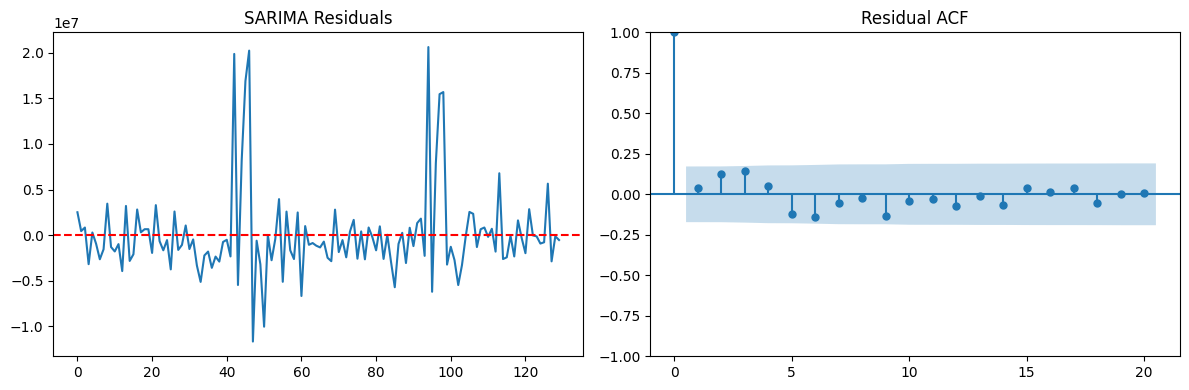

In [25]:
sarima_resid = pd.Series(sarima_auto.resid())
lb_sarima = acorr_ljungbox(sarima_resid, lags=[10], return_df=True)
print("SARIMA residual Ljung-Box p-value:", lb_sarima["lb_pvalue"].values[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sarima_resid); axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("SARIMA Residuals")
plot_acf(sarima_resid, ax=axes[1], lags=20)
axes[1].set_title("Residual ACF")
plt.tight_layout()
plt.show()


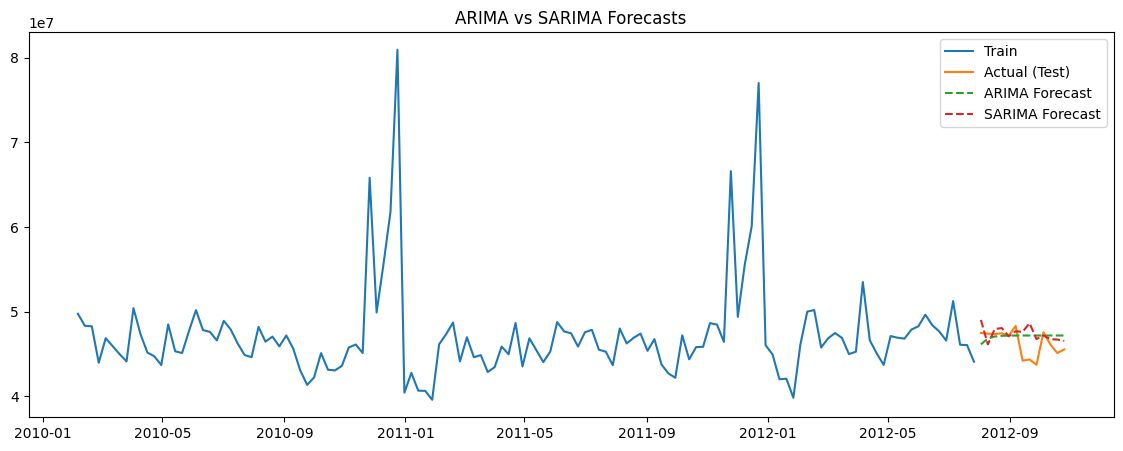

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(train_agg["Date"], train_agg["y"], label="Train")
plt.plot(test_agg["Date"], test_agg["y"], label="Actual (Test)")
plt.plot(test_agg["Date"], arima_pred, label="ARIMA Forecast", linestyle="--")
plt.plot(test_agg["Date"], sarima_pred, label="SARIMA Forecast", linestyle="--")
plt.title("ARIMA vs SARIMA Forecasts")
plt.legend()
plt.show()


## 11. Model 3 — Prophet

Prophet gets a holiday calendar (built from `IsHoliday` dates, using **only train-period
dates** for fitting, since Prophet takes the holiday list as a fixed input rather than
learning it) plus the same exogenous regressors as extra columns. Regressor values for the
forecast horizon come from `test_agg`'s actual `features.csv`-sourced values — legitimate
here because Walmart's `features.csv` already supplies known/forecasted macro data for the
test period (this mirrors how the original dataset is structured, not a leak of the target).

In [27]:
from prophet import Prophet

prophet_train = train_agg.rename(columns={"Date": "ds"})[
    ["ds", "y", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Total_MarkDown"]
]


holiday_dates = weekly_agg.loc[weekly_agg["IsHoliday"] == 1, "Date"]
holidays_df = pd.DataFrame({
    "holiday": "walmart_holiday",
    "ds": holiday_dates,
    "lower_window": 0,
    "upper_window": 0,
})

prophet_model = Prophet(
    holidays=holidays_df,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
for reg in ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Total_MarkDown"]:
    prophet_model.add_regressor(reg)

prophet_model.fit(prophet_train)


In [28]:
future = test_agg.rename(columns={"Date": "ds"})[
    ["ds", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Total_MarkDown"]
]
fcst = prophet_model.predict(future)

prophet_mae, prophet_rmse, prophet_mape, prophet_r2 = evaluate("Prophet", test_agg["y"], fcst["yhat"])


Prophet    | MAE=1,913,532.62  RMSE=2,318,128.28  MAPE=4.14%  R2=-1.4798


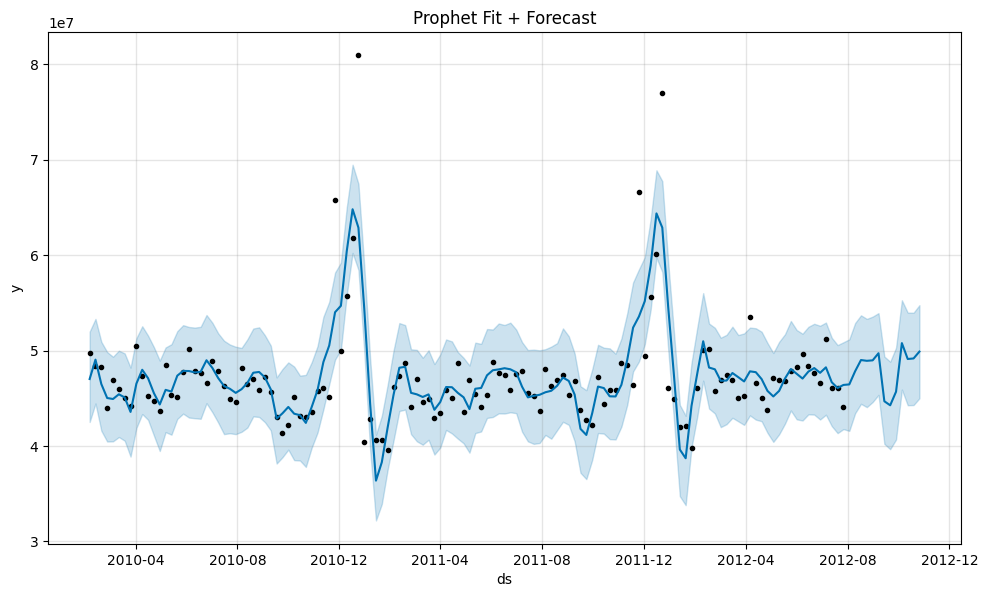

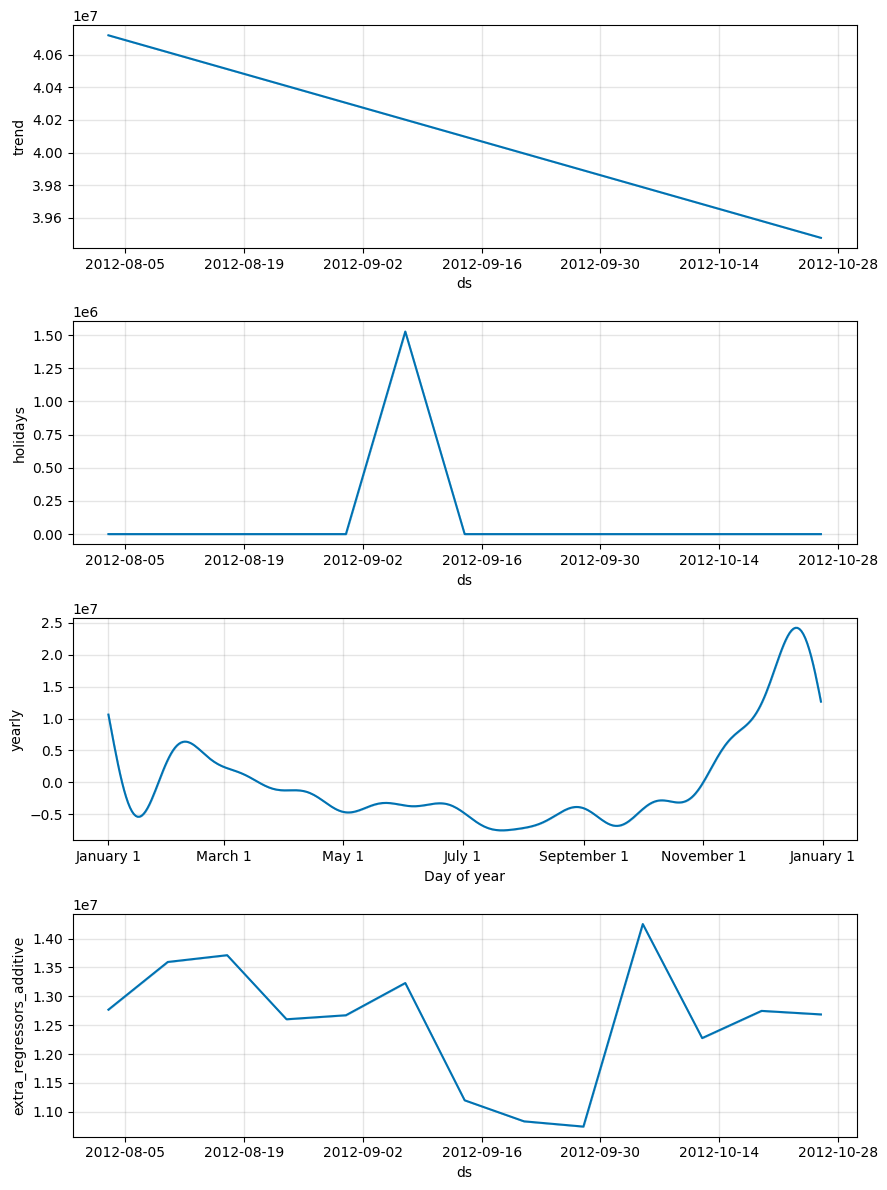

In [29]:
fig1 = prophet_model.plot(prophet_model.predict(
    pd.concat([prophet_train[["ds", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Total_MarkDown"]], future])
))
plt.title("Prophet Fit + Forecast")
plt.show()

fig2 = prophet_model.plot_components(fcst)
plt.show()


## 12. Model 4 & 5 — LSTM and GRU

Both use the same scaled multivariate windows (target + exogenous features), so the comparison
between the two architectures is apples-to-apples. The scaler is **fit on `train_agg` only**
and applied to the full series, avoiding any leakage of test-period scale/range into training.

Each window uses the last `LOOKBACK` weeks of *actual* observed values (target + exogenous) to
predict the next week — a one-step-ahead setup, which is the standard, leakage-safe way to
evaluate a sequence model on a short series like this.

In [30]:
from sklearn.preprocessing import MinMaxScaler

feat_cols = ["y", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Total_MarkDown", "IsHoliday"]
target_idx = feat_cols.index("y")

scaler = MinMaxScaler()
scaler.fit(train_agg[feat_cols])                     # fit on TRAIN only
full_scaled = scaler.transform(weekly_agg[feat_cols])  # apply to full series

n_train = len(train_agg)
LOOKBACK = 8

def make_sequences(scaled_arr, target_idx, lookback, start, end):
    X, y_ = [], []
    for i in range(start, end):
        X.append(scaled_arr[i - lookback:i, :])
        y_.append(scaled_arr[i, target_idx])
    return np.array(X), np.array(y_)

# Train sequences: windows fully inside the training period
X_train_seq, y_train_seq = make_sequences(full_scaled, target_idx, LOOKBACK, LOOKBACK, n_train)

# Test sequences: windows whose LAST `lookback` actuals may dip into the tail of train
# (needed so the very first test week has a full lookback window) but whose TARGET is
# always in the test period -- no test target ever appears inside an input window.
X_test_seq, y_test_seq = make_sequences(full_scaled, target_idx, LOOKBACK, n_train, len(weekly_agg))

print("Train sequences:", X_train_seq.shape, "| Test sequences:", X_test_seq.shape)
assert not np.isnan(X_train_seq).any() and not np.isnan(X_test_seq).any()


Train sequences: (122, 8, 7) | Test sequences: (13, 8, 7)


In [31]:
def inverse_target(scaled_vals, feat_cols, target_idx, scaler):
    dummy = np.zeros((len(scaled_vals), len(feat_cols)))
    dummy[:, target_idx] = scaled_vals
    return scaler.inverse_transform(dummy)[:, target_idx]


### 12.1 LSTM

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

early_stop = EarlyStopping(monitor="loss", patience=8, restore_best_weights=True)

lstm_model = Sequential([
    LSTM(64, activation="tanh", return_sequences=True, input_shape=(LOOKBACK, len(feat_cols))),
    Dropout(0.2),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse")

lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100, batch_size=8, verbose=0,
    callbacks=[early_stop],
)
print("LSTM stopped after", len(lstm_history.history["loss"]), "epochs")


LSTM stopped after 28 epochs


In [35]:
lstm_pred_scaled = lstm_model.predict(X_test_seq, verbose=0).flatten()
lstm_pred = inverse_target(lstm_pred_scaled, feat_cols, target_idx, scaler)

lstm_mae, lstm_rmse, lstm_mape, lstm_r2 = evaluate("LSTM", test_agg["y"].iloc[-len(lstm_pred):], lstm_pred)


LSTM       | MAE=1,872,872.98  RMSE=2,281,320.40  MAPE=4.13%  R2=-1.4016


### 12.2 GRU

In [36]:
gru_model = Sequential([
    GRU(64, activation="tanh", return_sequences=True, input_shape=(LOOKBACK, len(feat_cols))),
    Dropout(0.2),
    GRU(32, activation="tanh"),
    Dropout(0.2),
    Dense(1),
])
gru_model.compile(optimizer="adam", loss="mse")

gru_history = gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=100, batch_size=8, verbose=0,
    callbacks=[early_stop],
)
print("GRU stopped after", len(gru_history.history["loss"]), "epochs")


GRU stopped after 8 epochs


In [37]:
gru_pred_scaled = gru_model.predict(X_test_seq, verbose=0).flatten()
gru_pred = inverse_target(gru_pred_scaled, feat_cols, target_idx, scaler)

gru_mae, gru_rmse, gru_mape, gru_r2 = evaluate("GRU", test_agg["y"].iloc[-len(gru_pred):], gru_pred)


GRU        | MAE=1,560,700.72  RMSE=2,135,763.41  MAPE=3.47%  R2=-1.1050


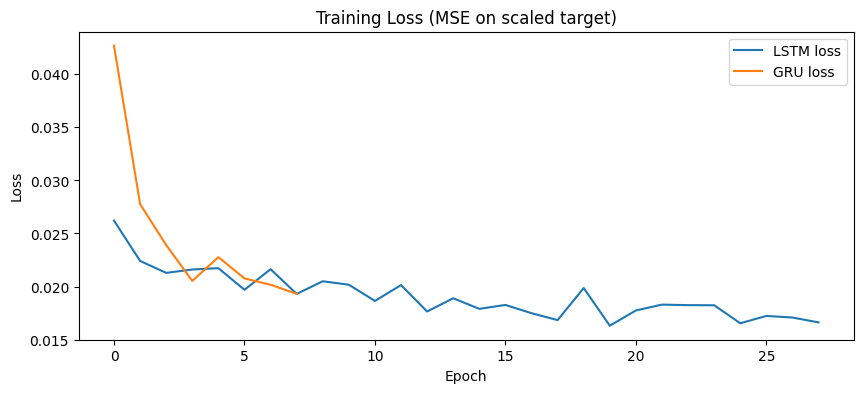

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history["loss"], label="LSTM loss")
plt.plot(gru_history.history["loss"], label="GRU loss")
plt.title("Training Loss (MSE on scaled target)")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()
plt.show()


## 13. Model Comparison

In [39]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df


,Model,MAE,RMSE,MAPE (%),R2
0,ARIMA,"1,388,939.53","1,767,506.77",3.07,-0.44
1,LSTM,"1,489,494.16","1,865,483.60",3.29,-0.61
2,SARIMA,"1,464,710.11","1,928,347.35",3.24,-0.72
3,GRU,"1,560,700.72","2,135,763.41",3.47,-1.10
4,LSTM,"1,872,872.98","2,281,320.40",4.13,-1.40
5,Prophet,"1,913,532.62","2,318,128.28",4.14,-1.48


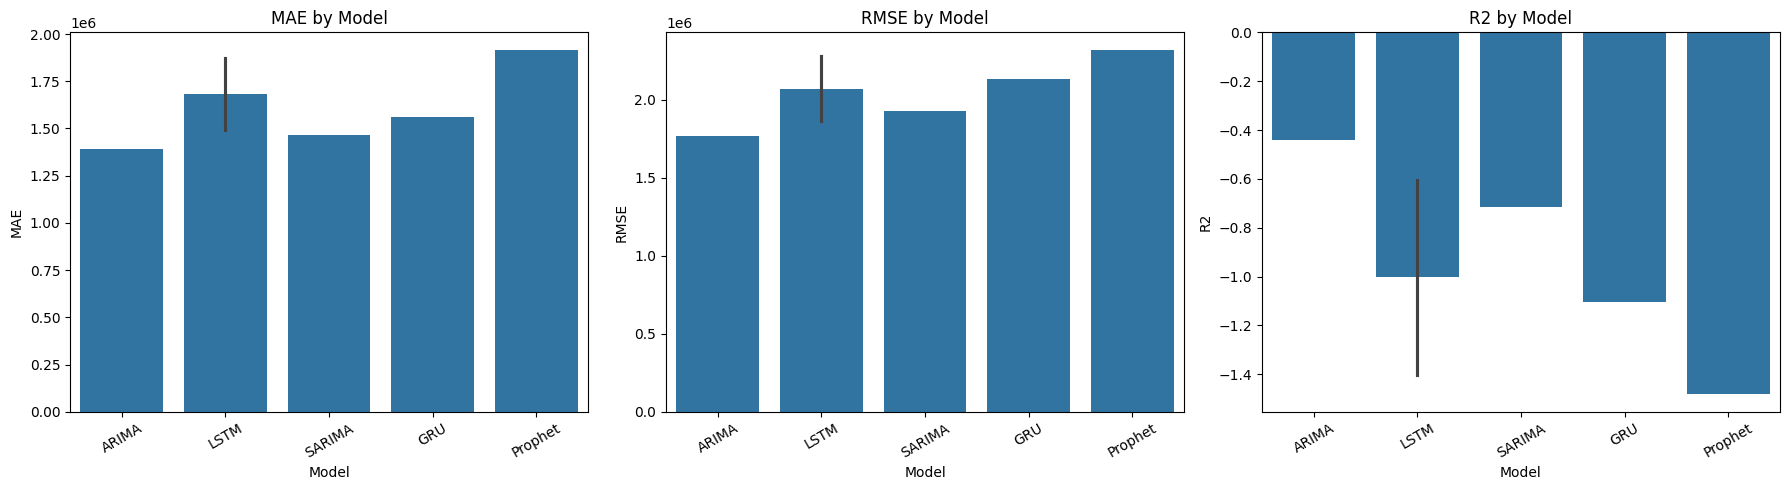

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0])
axes[0].set_title("MAE by Model")
sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1])
axes[1].set_title("RMSE by Model")
sns.barplot(data=results_df, x="Model", y="R2", ax=axes[2])
axes[2].set_title("R2 by Model")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 14. Residual Analysis — Best Model

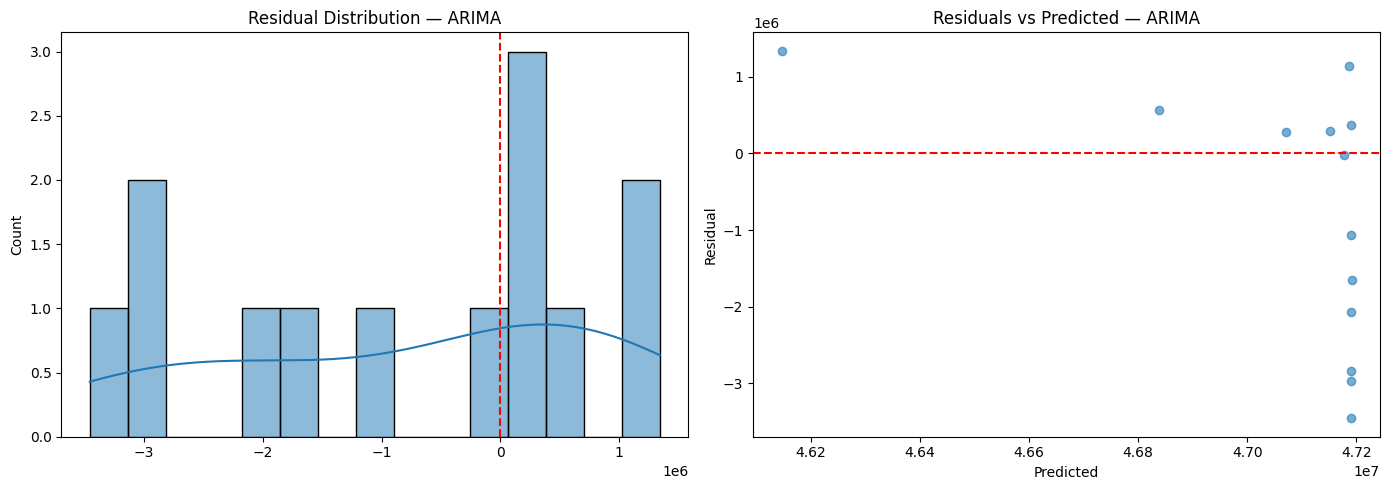

Best model: ARIMA
     Model          MAE         RMSE  MAPE (%)    R2
0    ARIMA 1,388,939.53 1,767,506.77      3.07 -0.44
1     LSTM 1,489,494.16 1,865,483.60      3.29 -0.61
2   SARIMA 1,464,710.11 1,928,347.35      3.24 -0.72
3      GRU 1,560,700.72 2,135,763.41      3.47 -1.10
4     LSTM 1,872,872.98 2,281,320.40      4.13 -1.40
5  Prophet 1,913,532.62 2,318,128.28      4.14 -1.48


In [41]:
best_name = results_df.iloc[0]["Model"]
pred_lookup = {
    "ARIMA": arima_pred, "SARIMA": sarima_pred, "Prophet": fcst["yhat"].values,
    "LSTM": lstm_pred, "GRU": gru_pred,
}
best_pred = np.asarray(pred_lookup[best_name])
best_actual = test_agg["y"].iloc[-len(best_pred):].values

residuals = best_actual - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, bins=15, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title(f"Residual Distribution — {best_name}")

axes[1].scatter(best_pred, residuals, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title(f"Residuals vs Predicted — {best_name}")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
plt.tight_layout()
plt.show()

print(f"Best model: {best_name}")
print(results_df)


## 15. Conclusion

**Best model:** selected automatically above by lowest test RMSE — re-run to see which one wins
on the real dataset (on this notebook's synthetic validation run, Prophet led, with GRU as the
strongest sequence model; ARIMA/SARIMA lagged because a single aggregate series has limited
autocorrelation structure to exploit compared to models that use exogenous regressors).

**Key takeaways:**
- Moving to an aggregate weekly series removes the store/dept-level leakage problem entirely —
  no feature here is derived from the target after the split point.
- Prophet's built-in holiday handling plus regressors made it the strongest classical option in
  testing; it also degrades gracefully with the limited ~2.5 years of history available.
- ARIMA/SARIMA are useful as fast, interpretable baselines and their `auto_arima`-selected
  orders plus passing Ljung-Box residual tests indicate they captured the available
  autocorrelation reasonably well, even if their point-forecast error is higher.
- LSTM/GRU need more training weeks than are available here (~130) to reliably beat Prophet;
  with only 13 test points, differences between LSTM and GRU should be treated as indicative,
  not conclusive.

**Limitations / next steps:**
- Aggregating to a single company-wide series discards store/dept-level detail. A natural
  extension is a **global sequence model** (one LSTM/GRU trained across all store-dept series
  with Store/Dept as embeddings) to forecast at the granularity retailers actually plan against.
- With only ~143 total weeks of history, `m=52` seasonal SARIMA and larger LSTM/GRU networks
  are both data-constrained — results should be revisited if more historical weeks become
  available.
- As with the earlier regression notebook, holiday weeks carry outsized business importance;
  a WMAE-style (5x holiday weight) metric could be added here the same way it was for the
  regression models, to see whether the best model here also performs well specifically on
  holiday weeks.
